# 🚗 Road Accident Analysis — Data Quality Assessment

### UK Road Safety Collision Data — 2025

**Project Stage:** Data Quality Assessment  
**Dataset:** `collisions_2025.csv`  
**Source:** UK Department for Transport (DfT)

---

## Purpose of This Notebook

The purpose of this notebook is to assess the quality, consistency, completeness,
and reliability of the raw road collision dataset before performing any data
cleaning or exploratory analysis.

The assessment will focus on:

- Missing values
- Duplicate records
- Duplicate identifiers
- Data types
- Unique values
- Unexpected categories
- Zero values
- Negative values
- Date and time validity
- Geographic validity
- Logical consistency
- Potential data-quality issues

> **Important:** No data-cleaning transformations will be performed in this notebook.
> The raw dataset will remain unchanged.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Load raw dataset

In [2]:
# Load the raw collision dataset

df = pd.read_csv("../01_Raw_Data/collisions_2025.csv")

print("Raw dataset loaded successfully!")

Raw dataset loaded successfully!


### Verify Dataset

In [3]:
# Check the number of rows and columns

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 101525
Number of columns : 44


In [4]:
# Check data types of all columns

df.dtypes

collision_index                                         str
collision_year                                        int64
collision_ref_no                                        str
location_easting_osgr                               float64
location_northing_osgr                              float64
longitude                                           float64
latitude                                            float64
police_force                                          int64
collision_severity                                    int64
number_of_vehicles                                    int64
number_of_casualties                                  int64
date                                                    str
day_of_week                                           int64
time                                                    str
local_authority_district                              int64
local_authority_ons_district                            str
local_authority_highway                 

In [5]:
# Display complete dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101525 entries, 0 to 101524
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   101525 non-null  str    
 1   collision_year                                    101525 non-null  int64  
 2   collision_ref_no                                  101525 non-null  str    
 3   location_easting_osgr                             101523 non-null  float64
 4   location_northing_osgr                            101523 non-null  float64
 5   longitude                                         101523 non-null  float64
 6   latitude                                          101523 non-null  float64
 7   police_force                                      101525 non-null  int64  
 8   collision_severity                                101525 non-null  int64  
 9   number_of_vehic

### Missing Value Analysis

In [6]:
# Count missing values in each column

missing_count = df.isnull().sum()
missing_count.sort_values(ascending=False)

location_easting_osgr                               2
latitude                                            2
longitude                                           2
location_northing_osgr                              2
collision_ref_no                                    0
collision_year                                      0
collision_index                                     0
police_force                                        0
collision_severity                                  0
number_of_vehicles                                  0
number_of_casualties                                0
date                                                0
day_of_week                                         0
time                                                0
local_authority_district                            0
local_authority_ons_district                        0
local_authority_highway                             0
local_authority_highway_current                     0
first_road_class            

In [7]:
# Calculate missing-value percentage

missing_percentage = (df.isnull().mean() * 100).round(2)
missing_percentage.sort_values(ascending=False)

collision_index                                     0.0
collision_year                                      0.0
collision_ref_no                                    0.0
location_easting_osgr                               0.0
location_northing_osgr                              0.0
longitude                                           0.0
latitude                                            0.0
police_force                                        0.0
collision_severity                                  0.0
number_of_vehicles                                  0.0
number_of_casualties                                0.0
date                                                0.0
day_of_week                                         0.0
time                                                0.0
local_authority_district                            0.0
local_authority_ons_district                        0.0
local_authority_highway                             0.0
local_authority_highway_current                 

In [8]:
# Create a complete missing-value summary

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2),
    "Non_Missing_Count": df.notnull().sum()
})
missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)
missing_summary

,Missing_Count,Missing_Percentage,Non_Missing_Count
collision_index,0,0.0,101525
collision_year,0,0.0,101525
collision_ref_no,0,0.0,101525
location_easting_osgr,2,0.0,101523
location_northing_osgr,2,0.0,101523
longitude,2,0.0,101523
latitude,2,0.0,101523
police_force,0,0.0,101525
collision_severity,0,0.0,101525
number_of_vehicles,0,0.0,101525


In [9]:
# Display only columns that contain missing values

missing_columns = missing_summary[
    missing_summary["Missing_Count"] > 0
]
missing_columns

,Missing_Count,Missing_Percentage,Non_Missing_Count
location_easting_osgr,2,0.0,101523
location_northing_osgr,2,0.0,101523
longitude,2,0.0,101523
latitude,2,0.0,101523


In [10]:
# Check whether any column contains only missing values

completely_missing = df.columns[df.isnull().all()]
print("Completely missing columns:")

if len(completely_missing) == 0:
    print("None")
else:
    print(list(completely_missing))

Completely missing columns:
None


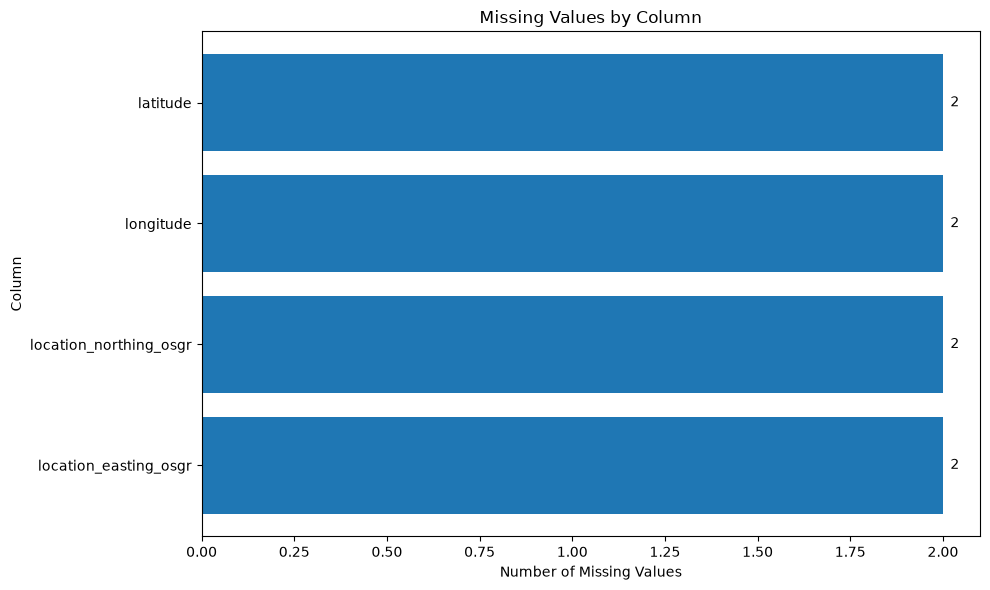

In [11]:
# Visualize missing values by column

missing_plot = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index,
    missing_plot["Missing_Count"]
)

plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.title("Missing Values by Column")

# Display the value at the end of each bar
for i, value in enumerate(missing_plot["Missing_Count"]):
    plt.text(
        value + 0.02,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

### Duplicate Analysis

In [12]:
# Count completely duplicated rows

duplicate_rows = df.duplicated().sum()
print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


In [13]:
# Calculate duplicate percentage

duplicate_percentage = (
    df.duplicated().mean() * 100
)
print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [14]:
# Display duplicated rows if any exist

if duplicate_rows > 0:
    df[df.duplicated(keep=False)].head(20)
else:
    print("No completely duplicated rows found.")

No completely duplicated rows found.


### Identifier Quality

In [15]:
# Check collision_index uniqueness

total_records = len(df)
unique_collision_index = df["collision_index"].nunique()
print("Total records:", total_records)
print("Unique collision_index values:", unique_collision_index)
print(
    "Duplicate collision_index values:",
    total_records - unique_collision_index
)

Total records: 101525
Unique collision_index values: 101525
Duplicate collision_index values: 0


In [16]:
# Check collision_ref_no uniqueness

unique_collision_ref = df["collision_ref_no"].nunique()

print("Total records:", total_records)
print("Unique collision_ref_no values:", unique_collision_ref)
print(
    "Duplicate collision_ref_no values:",
    total_records - unique_collision_ref
)

Total records: 101525
Unique collision_ref_no values: 101525
Duplicate collision_ref_no values: 0


In [17]:
# Check missing values in important identifiers

identifier_columns = [
    "collision_index",
    "collision_ref_no"
]

df[identifier_columns].isnull().sum()

collision_index     0
collision_ref_no    0
dtype: int64

### Unique Value Analysis

In [18]:
# Count unique values in every column

unique_counts = df.nunique().sort_values()
unique_counts

collision_year                                           1
local_authority_district                                 1
collision_injury_based                                   2
collision_severity                                       3
trunk_road_flag                                          3
urban_or_rural_area                                      3
did_police_officer_attend_scene_of_accident              3
pedestrian_crossing_human_control_historic               5
road_type                                                6
junction_control                                         6
speed_limit                                              6
enhanced_severity_collision                              6
light_conditions                                         6
first_road_class                                         7
road_surface_conditions                                  7
day_of_week                                              7
junction_detail                                         

In [19]:
# Identify columns with relatively few unique values

low_cardinality = unique_counts[
    unique_counts <= 20
]
low_cardinality

collision_year                                       1
local_authority_district                             1
collision_injury_based                               2
collision_severity                                   3
trunk_road_flag                                      3
urban_or_rural_area                                  3
did_police_officer_attend_scene_of_accident          3
pedestrian_crossing_human_control_historic           5
road_type                                            6
junction_control                                     6
speed_limit                                          6
enhanced_severity_collision                          6
light_conditions                                     6
first_road_class                                     7
road_surface_conditions                              7
day_of_week                                          7
junction_detail                                      8
carriageway_hazards_historic                         8
pedestrian

### Numerical Data Quality

In [20]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
print(list(numerical_columns))

Number of numerical columns: 36

Numerical columns:
['collision_year', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'local_authority_district', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'enhanced_severity_collision', 'collision_injury_based', 'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight']


In [21]:
# Count negative values in numerical columns

negative_values = (
    (df[numerical_columns] < 0)
    .sum()
    .sort_values(ascending=False)
)
negative_values

local_authority_district                            101525
junction_detail_historic                             87871
special_conditions_at_site                           87858
pedestrian_crossing_human_control_historic           87852
carriageway_hazards_historic                         87852
pedestrian_crossing_physical_facilities_historic     87851
longitude                                            86359
junction_control                                     44487
second_road_number                                   25105
enhanced_severity_collision                          13677
trunk_road_flag                                       7108
junction_detail                                       6701
pedestrian_crossing                                   6527
carriageway_hazards                                   5346
road_surface_conditions                                634
second_road_class                                      171
light_conditions                                        

### Zero Value Analysis

In [22]:
# Count zero values in numerical columns

zero_values = (
    (df[numerical_columns] == 0)
    .sum()
    .sort_values(ascending=False)
)
zero_values

carriageway_hazards                                 91375
pedestrian_crossing                                 74538
collision_adjusted_severity_serious                 69042
second_road_number                                  59134
junction_detail                                     45333
first_road_number                                   41465
collision_adjusted_severity_slight                  26110
second_road_class                                   24886
collision_injury_based                              13677
carriageway_hazards_historic                        13225
special_conditions_at_site                          13171
pedestrian_crossing_human_control_historic          13092
pedestrian_crossing_physical_facilities_historic    10692
junction_detail_historic                             5411
location_easting_osgr                                   0
collision_year                                          0
longitude                                               0
location_north

In [23]:
# Calculate percentage of zero values

zero_percentage = (
    (df[numerical_columns] == 0).mean() * 100
).round(2)
zero_percentage.sort_values(ascending=False)

carriageway_hazards                                 90.00
pedestrian_crossing                                 73.42
collision_adjusted_severity_serious                 68.00
second_road_number                                  58.25
junction_detail                                     44.65
first_road_number                                   40.84
collision_adjusted_severity_slight                  25.72
second_road_class                                   24.51
collision_injury_based                              13.47
carriageway_hazards_historic                        13.03
special_conditions_at_site                          12.97
pedestrian_crossing_human_control_historic          12.90
pedestrian_crossing_physical_facilities_historic    10.53
junction_detail_historic                             5.33
location_easting_osgr                                0.00
collision_year                                       0.00
longitude                                            0.00
location_north

In [49]:
# Check collision year values

print("Unique collision years:")
print(sorted(df["collision_year"].dropna().unique()))

Unique collision years:
[np.int64(2025)]


In [25]:
# Check number of vehicles

print(df["number_of_vehicles"].describe())
print(
    "\nMinimum vehicles:",
    df["number_of_vehicles"].min()
)

print(
    "\nMaximum vehicles:",
    df["number_of_vehicles"].max()
)

count    101525.000000
mean          1.811849
std           0.689631
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          17.000000
Name: number_of_vehicles, dtype: float64

Minimum vehicles: 1

Maximum vehicles: 17


In [50]:
# Check number of casualties

print(df["number_of_casualties"].describe())

print(
    "\nMinimum casualties:",
    df["number_of_casualties"].min()
)

print(
    "Maximum casualties:",
    df["number_of_casualties"].max()
)

count    101525.000000
mean          1.259621
std           0.816679
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         142.000000
Name: number_of_casualties, dtype: float64

Minimum casualties: 1
Maximum casualties: 142


### Speed Limit Quality

In [27]:
# Examine speed limit values

speed_limit_counts = (
    df["speed_limit"]
    .value_counts(dropna=False)
    .sort_index()
)
speed_limit_counts

speed_limit
20    20045
30    49673
40     8886
50     4612
60    12709
70     5600
Name: count, dtype: int64

In [28]:
# Identify unusual speed-limit values

print("Minimum speed limit:", df["speed_limit"].min())
print("Maximum speed limit:", df["speed_limit"].max())

Minimum speed limit: 20
Maximum speed limit: 70


### Date Quality

In [29]:
# Check the current data type of the date column

print("Date data type:", df["date"].dtype)

Date data type: str


In [30]:
# Display sample raw date values

df["date"].head(10)

0    05/03/2025
1    03/10/2025
2    15/11/2025
3    23/12/2025
4    06/02/2025
5    05/03/2025
6    28/06/2025
7    19/08/2025
8    02/09/2025
9    03/08/2025
Name: date, dtype: str

In [31]:
# Count missing dates

print("Missing date values:", df["date"].isnull().sum())

Missing date values: 0


In [32]:
# Test whether date values can be parsed successfully

parsed_dates = pd.to_datetime(
    df["date"],
    errors="coerce",
    dayfirst=True
)

invalid_dates = (
    df["date"].notna() & parsed_dates.isna()
).sum()

print("Invalid date values:", invalid_dates)

Invalid date values: 0


### Time Quality

In [33]:
# Examine raw time values

print("Time data type:", df["time"].dtype)
df["time"].head(10)

Time data type: str


0    12:50
1    18:35
2    21:00
3    01:44
4    08:52
5    13:12
6    14:16
7    07:00
8    09:13
9    20:30
Name: time, dtype: str

In [34]:
# Count missing time values

print("Missing time values:", df["time"].isnull().sum())

Missing time values: 0


In [35]:
# Test whether time values can be interpreted as HH:MM

parsed_times = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
)

invalid_times = (
    df["time"].notna() & parsed_times.isna()
).sum()

print("Invalid time values:", invalid_times)

Invalid time values: 0


### Geographic Quality

In [36]:
# Check latitude values

print("Latitude summary:")
print(df["latitude"].describe())

Latitude summary:
count    101523.000000
mean         52.375658
std           1.308239
min          49.912530
25%          51.464460
50%          51.888640
75%          53.325860
max          60.345250
Name: latitude, dtype: float64


In [37]:
# Check longitude values

print("Longitude summary:")
print(df["longitude"].describe())

Longitude summary:
count    101523.000000
mean         -1.223959
std           1.356983
min          -7.417720
25%          -2.118700
50%          -1.138910
75%          -0.137910
max           1.755590
Name: longitude, dtype: float64


In [38]:
# Check missing geographic coordinates

print("Missing latitude:", df["latitude"].isnull().sum())
print("Missing longitude:", df["longitude"].isnull().sum())

Missing latitude: 2
Missing longitude: 2


In [39]:
# Check for coordinates outside valid geographic ranges

invalid_latitude = (
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
).sum()

invalid_longitude = (
    (df["longitude"] < -180) |
    (df["longitude"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Invalid latitude values: 0
Invalid longitude values: 0


### Categorical Quality

In [40]:
# Examine collision severity codes

df["collision_severity"].value_counts(
    dropna=False
).sort_index()

collision_severity
1     1453
2    25191
3    74881
Name: count, dtype: int64

In [41]:
# Examine road type codes

df["road_type"].value_counts(
    dropna=False
).sort_index()

road_type
1     6795
2     2398
3    14610
6    74150
7     1619
9     1953
Name: count, dtype: int64

In [42]:
# Examine weather condition codes

df["weather_conditions"].value_counts(
    dropna=False
).sort_index()

weather_conditions
1    83405
2    10230
3      235
4      715
5      880
6       19
7      342
8     3314
9     2385
Name: count, dtype: int64

In [43]:
# Examine road surface condition codes

df["road_surface_conditions"].value_counts(
    dropna=False
).sort_index()

road_surface_conditions
-1      634
 1    75679
 2    22312
 3      146
 4     1261
 5      151
 9     1342
Name: count, dtype: int64

In [44]:
# Examine light condition codes

df["light_conditions"].value_counts(
    dropna=False
).sort_index()

light_conditions
-1       16
 1    72814
 4    20705
 5      720
 6     5682
 7     1588
Name: count, dtype: int64

In [45]:
# Examine urban/rural classification codes

df["urban_or_rural_area"].value_counts(
    dropna=False
).sort_index()

urban_or_rural_area
1    67148
2    34373
3        4
Name: count, dtype: int64

### Logical Consistency Check

In [46]:
# Check whether collision records have zero vehicles

zero_vehicle_records = (
    df["number_of_vehicles"] == 0
).sum()

print("Records with zero vehicles:", zero_vehicle_records)# Check whether collision records have zero vehicles

zero_vehicle_records = (
    df["number_of_vehicles"] == 0
).sum()

print("Records with zero vehicles:", zero_vehicle_records)

Records with zero vehicles: 0
Records with zero vehicles: 0


In [47]:
# Check for records with zero casualties

zero_casualty_records = (
    df["number_of_casualties"] == 0
).sum()

print("Records with zero casualties:", zero_casualty_records)

Records with zero casualties: 0


### Data Quality Summary

In [48]:
# Create an overall data-quality summary

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Collision Index",
        "Duplicate Collision Reference"
    ],
    
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["collision_index"].duplicated().sum(),
        df["collision_ref_no"].duplicated().sum()
    ]
})

quality_summary

,Metric,Value
0,Total Rows,101525
1,Total Columns,44
2,Missing Values,8
3,Duplicate Rows,0
4,Duplicate Collision Index,0
5,Duplicate Collision Reference,0


## 8. Data Quality Findings

The data-quality assessment was performed before applying any cleaning
transformations.

The assessment covered:

- Dataset completeness
- Missing values
- Duplicate records
- Identifier uniqueness
- Data types
- Unique-value patterns
- Zero values
- Negative values
- Date validity
- Time validity
- Geographic coordinates
- Categorical-code distributions
- Logical consistency

The results from these checks will be used to determine the appropriate
data-cleaning strategy.

Importantly, not every missing value, zero value, or unusual value should
automatically be treated as an error. Each issue must be interpreted in
the context of the variable and the official DfT data definitions.

## 9. Data Quality Decision Framework

| Issue | Action |
|---|---|
| Missing values | Investigate before deciding how to handle |
| Duplicate rows | Verify whether they are genuine duplicates |
| Duplicate identifiers | Investigate identifier structure |
| Invalid data types | Correct during cleaning |
| Invalid dates | Investigate and correct if necessary |
| Invalid times | Investigate and correct if necessary |
| Invalid coordinates | Investigate before removal |
| Zero values | Determine whether zero is meaningful |
| Negative values | Validate according to variable meaning |
| Categorical codes | Decode using official DfT documentation |
| Outliers | Investigate before deciding whether to retain |

## 10. Conclusion

The Data Quality Assessment provides a detailed understanding of potential
quality issues within the 2025 road collision dataset.

The dataset should not be cleaned using a one-size-fits-all approach.
Missing values, zeros, negative values, coded categories, and unusual
observations must be interpreted according to the meaning of each variable.

The findings from this notebook will guide the next stage of the project:

### **Data Cleaning and Preparation**

During the next stage, we will:

1. Create a working copy of the raw dataset.
2. Handle missing values using appropriate methods.
3. Correct data types where required.
4. Decode categorical variables using the official DfT definitions.
5. Validate date and time variables.
6. Investigate and handle duplicates where appropriate.
7. Address invalid or inconsistent values.
8. Create useful analytical features.
9. Validate the cleaned dataset.
10. Export the cleaned dataset for EDA.